# Scenario risk quantification for "approaching slower vehicle"

In [20]:
# Do the necessary imports
from copy import deepcopy
import os
import numpy as np
from domain_model import DocumentManagement, StateVariable
from simulation import SimulationApproaching, acc_approaching_pars, acc_idm_approaching_pars, accaeb_approaching_pars, idm_approaching_pars,\
    IDMPlus, ACC, ACCAEB,  ACCIDMPlus, KDE, kde_from_file
from case_study import get_kpi, case_study, CaseStudy, sample_reactiontime, reactiontime_density

In [21]:
# By default, do not overwrite previous results. Set to True to rerun all simulations.
OVERWRITE = True

## Several simulations

Below, two simulations are performed. One in which the ego vehicle is controlled by the ACC with AEB, and one in which the human (modelled using IDM+) is in control.

In [22]:
simulator_accaeb = SimulationApproaching(followers=[ACCAEB()], followers_parameters=[accaeb_approaching_pars],
                                      min_simulation_time=5)

simulator_idmplus = SimulationApproaching(followers=[IDMPlus()], 
                                         followers_parameters=[idm_approaching_pars],
                                         min_simulation_time=5)

array([0.99976078])

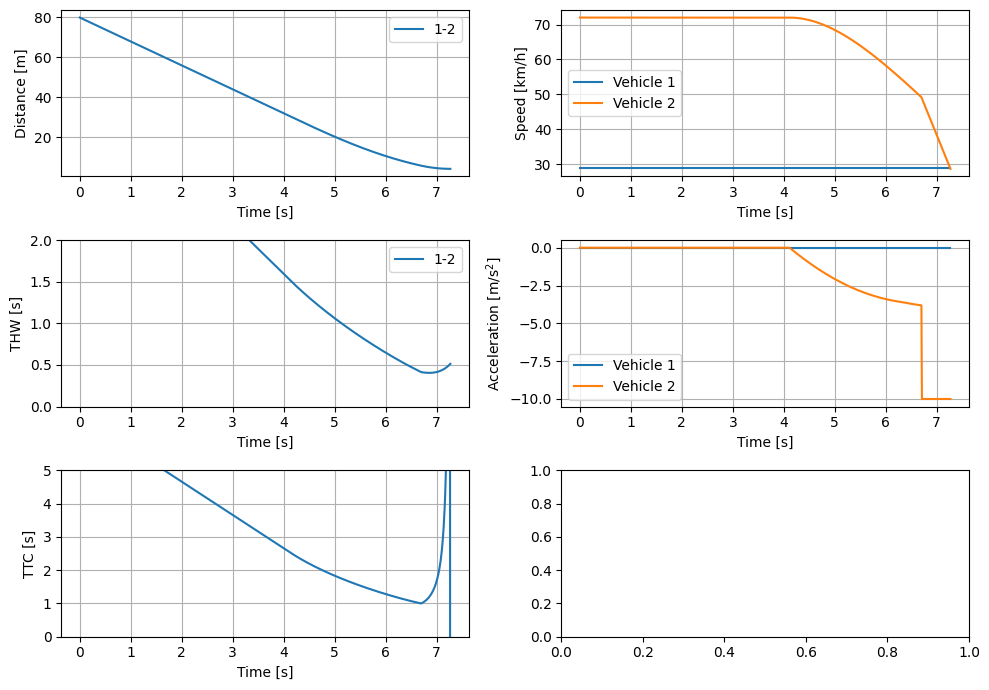

In [23]:
simulator_accaeb.simulation(dict(vego=20, ratio_vtar_vego=0.4), plot=True)

array([5.44916777])

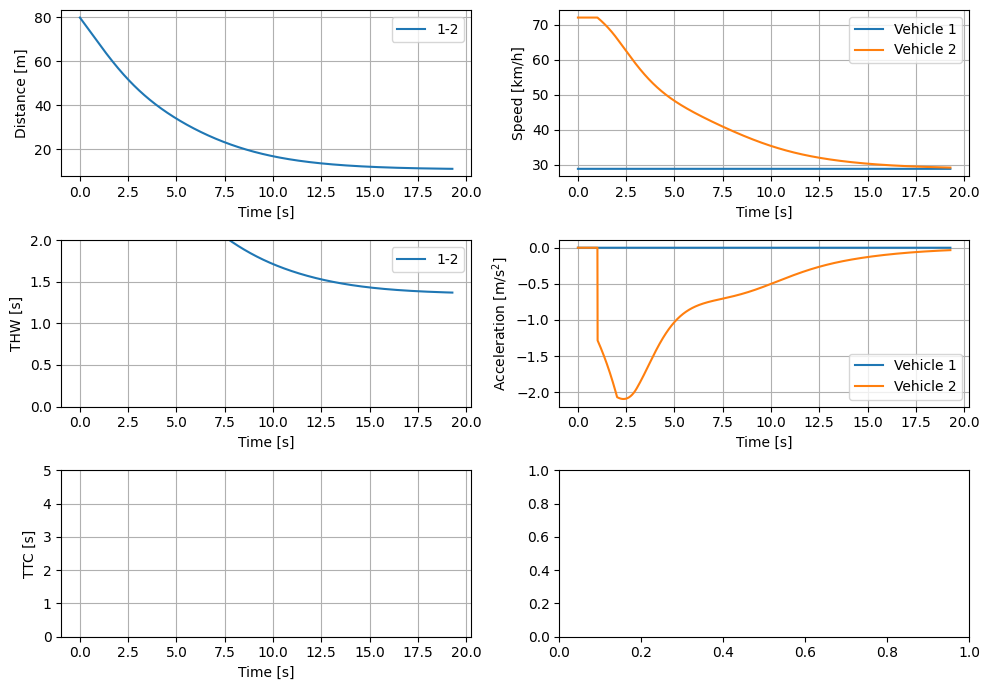

In [24]:

simulator_idmplus.simulation(dict(vego=20, ratio_vtar_vego=0.4), plot=True)


Let's limit the viewing range of the ego vehicle. Note that the driver now takes over at about 5.5 seconds into the simulation instead of 5 seconds.

## Create KDE of scenario parameters

In [25]:
# Load the data with the scenarios.
scenarios = DocumentManagement(os.path.join("data", "scenarios", "approaching_vehicle.json"))
print("Number of approaching slower vehicle scenarios: {:d}"
      .format(len(scenarios.collections["scenario"])))

Number of approaching slower vehicle scenarios: 291


In [26]:
filename = os.path.join("data", "kde", "approaching_slower_vehicle.p")
if os.path.exists(filename) and not OVERWRITE:
    kde = kde_from_file(filename)
else:
    pars = []
    for key in scenarios.collections["scenario"]:
        scenario = scenarios.get_item("scenario", key)
        vego = scenario.get_state(scenario.get_actor_by_name("ego vehicle"), StateVariable.SPEED,
                                  scenario.get_tstart())
        vtarget = scenario.get_state(scenario.get_actor_by_name("target vehicle"),
                                     StateVariable.LON_TARGET, scenario.get_tstart())[0]
        pars.append([vego, vtarget/vego])

    kde = KDE(np.array(pars))
    kde.compute_bandwidth()
    kde.pickle(filename)

c:\GIT\ScenarioRiskQuantification\simulation\fastkde.py:495: RuntimeWarning: divide by zero encountered in log
  score = (np.sum(np.log(np.sum(np.exp(self.data_helpers.mindists


## Perform the case study

#### Some functions that are needed

In [27]:
# Function that checks if the scenario parameters are valid.
def check_pars(pars):
    if pars[0] <= 0 or pars[1] < 0 or pars[1] >= 1:  # vego>0, 0<=ratio_vtar_vego<1
        return False
    if len(pars) > 2 and pars[2] <= 0:
        return False
    return True

# Function for sampling the parameters in case the ACCAEB model is used.
def func_sample_accaeb():
    return kde.sample()[0]

# Function for sampling the parameters in case the IDMPlus model is used.
def func_sample_idmplus():
    return np.concatenate((kde.sample()[0], [sample_reactiontime()]))

# Function for obtaining the pdf of the parameters in case the ACCAEB model is used.
def func_density_accaeb(pars):
    return kde.score_samples(pars)

# Function for obtaining the pdf of the parameters in case the IDMPlus model is used.
def func_density_idmplus(pars):
    return kde.score_samples(pars[:, :2]) * reactiontime_density(pars[:, 2])

#### With ACC, no triggering condition

In [28]:
default_parameters = dict(n=10000,
                          default_parameters=dict(amin=-6),
                          percentile=2,
                          func_validity_check=check_pars,
                          func_process_result=get_kpi)

In [29]:
#### With ACC & AEB, no triggering condition

In [38]:
pars_accaeb = dict(name="approaching_slower_accaeb",
                parameters=["vego", "ratio_vtar_vego"],
                simulator=simulator_accaeb,
                func_sample=func_sample_accaeb,
                func_density=func_density_accaeb)
pars_accaeb.update(default_parameters)
df_mc_accaeb, df_is_accaeb = case_study(CaseStudy(**pars_accaeb), overwrite=OVERWRITE)

100%|██████████| 10000/10000 [09:10<00:00, 18.17it/s]


Monte Carlo:
  Probability of collision: 6.60e-03 +/- 8.10e-04
  Probability of injury:    1.64e-05 +/- 2.10e-06


100%|██████████| 10000/10000 [02:42<00:00, 61.57it/s]

Importance sampling:
  Probability of collision: 7.66e-03 +/- 1.35e-04
  Probability of injury:    1.84e-05 +/- 3.26e-07


#### With ACC & IDM+, no triggering condition

In [39]:
pars_idmplus = dict(name="approaching_slower_idmplus",
                   parameters=["vego", "ratio_vtar_vego", "reactiontime"],
                   simulator=simulator_idmplus,
                   func_sample=func_sample_idmplus,
                   func_density=func_density_idmplus)
pars_idmplus.update(default_parameters)
df_mc_idmplus, df_is_idmplus = case_study(CaseStudy(**pars_idmplus), overwrite=OVERWRITE)

100%|██████████| 10000/10000 [24:38<00:00,  6.77it/s]
c:\GIT\ScenarioRiskQuantification\simulation\fastkde.py:495: RuntimeWarning: divide by zero encountered in log
  score = (np.sum(np.log(np.sum(np.exp(self.data_helpers.mindists


Monte Carlo:
  Probability of collision: 0.00e+00 +/- 0.00e+00
  Probability of injury:    0.00e+00 +/- 0.00e+00


100%|██████████| 10000/10000 [14:07<00:00, 11.79it/s]


Importance sampling:
  Probability of collision: 4.77e-08 +/- 4.77e-08
  Probability of injury:    6.53e-11 +/- 6.53e-11


In [52]:
df_mc_accaeb[df_mc_accaeb.result == df_mc_accaeb.result.max()]

,vego,ratio_vtar_vego,tries,result,kpi
1235,29.384663,0.997538,1.0,1000.0,0.0


<Axes: >

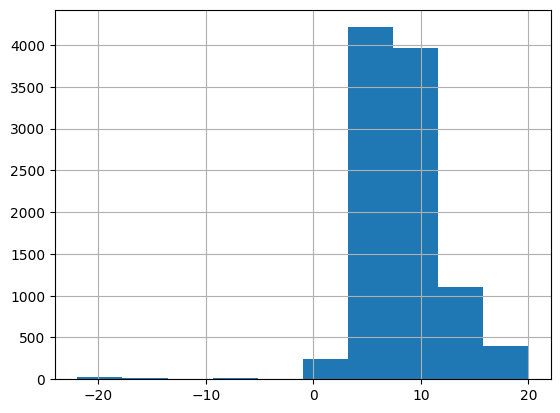

In [62]:
df_mc_accaeb.result.clip(upper =20).hist()

<Axes: >

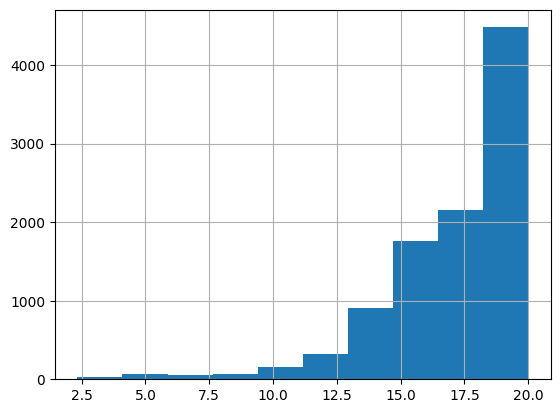

In [60]:
df_mc_idmplus.result.clip(upper =20).hist()

#### With ACC, triggering condition: low $\mu$

In [ ]:
AMIN = -3  # Corresponding to mu=0.3

In [ ]:
pars = deepcopy(pars_acc)
pars["default_parameters"].update(dict(amin=AMIN))
pars["name"] = "lowmu_approaching_slower_acc"
df_mc, df_is = case_study(CaseStudy(**pars), overwrite=OVERWRITE)

#### With ACC & IDM+, triggering condition: low $\mu$

In [ ]:
pars = deepcopy(pars_accidm)
pars["default_parameters"].update(dict(amin=AMIN))
pars["name"] = "lowmu_approaching_slower_accidm"
df_mc, df_is = case_study(CaseStudy(**pars), overwrite=OVERWRITE)

#### With ACC, triggering condition: low visibility

Result is exactly the same as without this triggering condition, so no need to redo the simulations

In [ ]:
MAX_VIEW = 60  # [m]

In [ ]:
df_mc, df_is = case_study(CaseStudy(**pars_acc), overwrite=False)

#### With ACC & IDM+, triggering condition: low visibility

In [ ]:
pars = deepcopy(pars_accidm)
pars["default_parameters"].update(dict(max_view=MAX_VIEW))
pars["name"] = "late_approaching_slower_accidm"
df_mc, df_is = case_study(CaseStudy(**pars), overwrite=OVERWRITE)